In [3]:
# imports and data
import pandas as pd
import math
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
from scipy import stats
import seaborn as sns
import plotly.express as px
import ipywidgets as widgets
from IPython.display import display



In [4]:
"""
# This will help us create numbered figure titles consistently throughout the notebook.
# If encounter any issues with increasing numbers in a plot title, please run all cells again.
fig_counter = 1


def create_figure_title(title, label=None):
    #Helper function to create numbered figure titles with optional smaller subtitle
    global fig_counter
    if label:
        # Use newline and indicate smaller text - matplotlib will respect fontsize on the whole title
        # but we can visually separate it
        fig_title = f"Figure {fig_counter}: {title}\n{label}"
    else:
        fig_title = f"Figure {fig_counter}: {title}"
    fig_counter += 1
    return fig_title


def display_fig_caption(caption_text):
    #Display a markdown caption with the current figure number
    from IPython.display import Markdown, display
    display(Markdown(f"**Figure {fig_counter}**: {caption_text}"))


def display_markdown_with_fig(markdown_text):
    #Display markdown text with {fig_counter} replaced by the current counter value
    from IPython.display import Markdown, display
    formatted_text = markdown_text.replace("{fig_counter}", str(fig_counter))
    display(Markdown(formatted_text))
"""

'\n# This will help us create numbered figure titles consistently throughout the notebook.\n# If encounter any issues with increasing numbers in a plot title, please run all cells again.\nfig_counter = 1\n\n\ndef create_figure_title(title, label=None):\n    #Helper function to create numbered figure titles with optional smaller subtitle\n    global fig_counter\n    if label:\n        # Use newline and indicate smaller text - matplotlib will respect fontsize on the whole title\n        # but we can visually separate it\n        fig_title = f"Figure {fig_counter}: {title}\n{label}"\n    else:\n        fig_title = f"Figure {fig_counter}: {title}"\n    fig_counter += 1\n    return fig_title\n\n\ndef display_fig_caption(caption_text):\n    #Display a markdown caption with the current figure number\n    from IPython.display import Markdown, display\n    display(Markdown(f"**Figure {fig_counter}**: {caption_text}"))\n\n\ndef display_markdown_with_fig(markdown_text):\n    #Display markdown tex

In [5]:
# Load the dataset
df_fc = pd.read_csv(
    "data/focus_crimes.csv",
    parse_dates=["incident_date"],
    low_memory=False
)

In [6]:
# create a datetime column by combining date and time, coercing errors to NaT and ensuring the correct format (float64)
df_fc["incident_datetime"] = pd.to_datetime(
    df_fc["incident_date"].astype(str) + " " + df_fc["incident_time"].astype(str),
    errors="coerce"
)
# set col order to have datetime before date and time
cols = df_fc.columns.tolist()
cols.insert(1, cols.pop(cols.index("incident_datetime")))
df_fc = df_fc[cols]

# Excluding year 2026 as its incomplete
df_fc = df_fc[df_fc["incident_datetime"].dt.year < 2026]
df_fc_original = df_fc.copy()

# Excluding year 2026 as its incomplete
df_fc = df_fc[df_fc["incident_datetime"].dt.year < 2026]
df_fc_original = df_fc.copy()

# incidents using pandas
year_counts = (
    df_fc["incident_datetime"]
    .dt.year
    .value_counts()
    .sort_index()
)


---
## Assignment 1.1: Temporal Overview

Let's start by getting the big picture of how crime has changed over the full 20+ year period covered by your combined dataset.

*Draws from*: Week 1, Exercises 4.1 and 4.2 — applied here to the full merged dataset (2003–present) rather than just 2018–present.

> * Using your combined dataset (2003–present), plot the total number of incidents **per year** for each of your Personal Focus Crimes. Display at least the years 2003–2025.
> * Make sure your plot follows good visualization practices: labeled axes, a legend, a descriptive title.
> * Identify and comment on at least two notable features in the plot — for example, long-term trends, sudden drops or spikes, or the impact of COVID-19 in 2020. For each feature, offer a possible explanation.

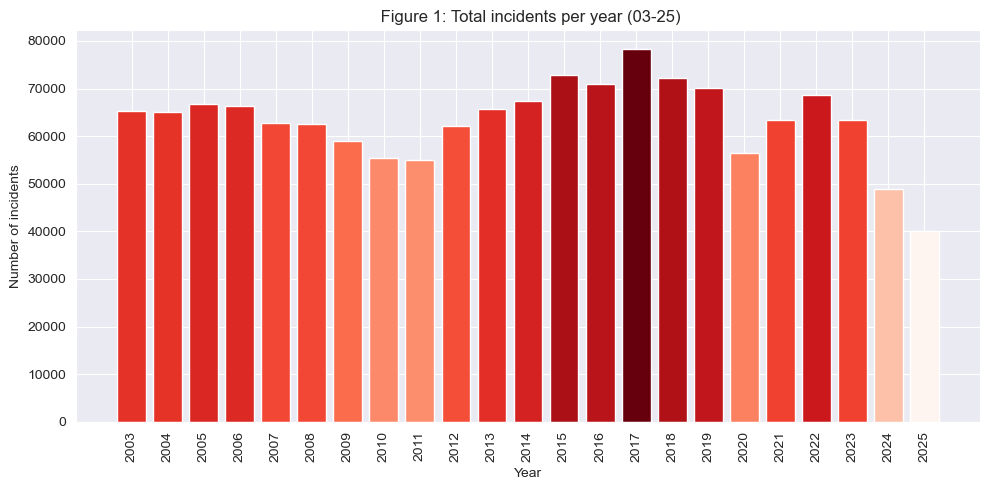

In [7]:
# normalize counts for color mapping (scale to [0,1])
norm = mcolors.Normalize(vmin=year_counts.min(), vmax=year_counts.max())
cmap = cm.Reds  # strong = dark, weak = light

colors = cmap(norm(year_counts.values))

plt.figure(figsize=(10, 5))
plt.bar(year_counts.index.astype(str), year_counts.values, color=colors)

plt.xlabel("Year")
plt.ylabel("Number of incidents")
plt.title(f" Figure 1: Total incidents per year (03-25)")

# rotate x-axis labels vertically
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()

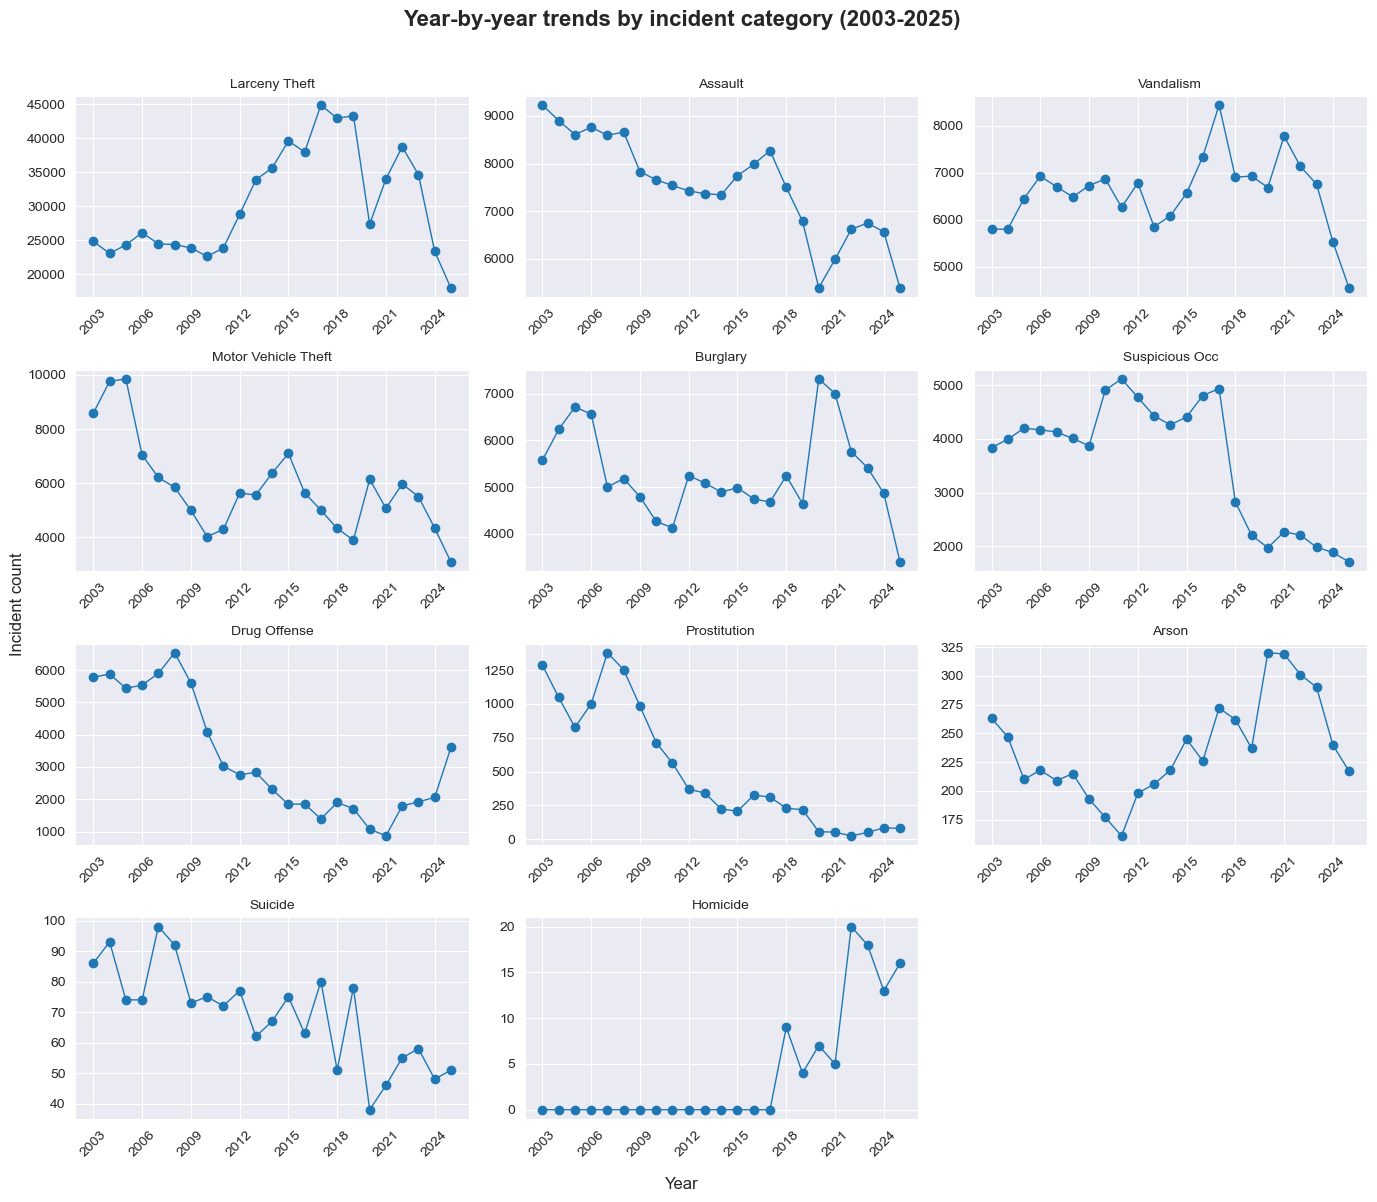

In [8]:
# exclude incomplete year (2026)
df_plot = df_fc[df_fc["incident_datetime"].dt.year < 2026].copy()
df_plot["year"] = df_plot["incident_datetime"].dt.year

# counts per (year, category)
pivot = (
    df_plot.groupby(["year", "incident_category"])
    .size()
    .unstack("incident_category", fill_value=0)
    .astype(int)
    .sort_index()
)

years = pivot.index.to_list()

# order categories: Total counts across all years, ascending
categories = pivot.sum(axis=0).sort_values(ascending=False).index.to_list()

# grid size based on number of categories
n = len(categories)
ncols = 3
nrows = math.ceil(n / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3.0 * nrows), sharex=True)
axes = axes.ravel()
xticks = years[::3]

for i, crime in enumerate(categories):
    ax = axes[i]
    ax.plot(years, pivot[crime].values, marker="o", linewidth=1)
    ax.set_title(crime.replace("_", " ").title(), fontsize=10)

    ax.set_xticks(xticks)
    ax.set_xticklabels(xticks, rotation=45)
    ax.tick_params(axis="x", labelbottom=True)

# turn off unused axes
for j in range(n, len(axes)):
    axes[j].axis("off")

fig.supylabel("Incident count")
fig.supxlabel("Year")
fig.suptitle("Year-by-year trends by incident category (2003-2025)",
             fontsize=16, fontweight='bold', y=0.995)

plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Notable Features in San Francisco Crime Trends (2003–2025)

##### **COVID-19 trend (2020–2022): some categories fall, others rise**
**Larceny theft, assault, and suicide decline** around the pandemic period, while categories such as **burglary, motor vehicle theft, vandalism, and arson increase** (or spike) in the period of 2020–2022.
A plausible explanation is that COVID changed *where* and *how* opportunities appeared: fewer people in dense retail/tourist areas reduces street/retail theft and some interpersonal incidents. That could priovide an explaination on why we see declines in **Larceny theft and assult**.
For the same reasons, we see increases in **burglery and motor vehicle theft**, as public spaces are empty and buildings are left unattended. In the same period we saw The George Floyd protests in 2020 which could have created a short-term shock to some categories. **Arson (low volume)** shows a  spike where a small number of additional incidents produces a visible annual peak (because of the low volume of crimes). On the other hand it would be natural apply the same reasoning to **vandalism (high volume)**. However, because of the high volume of crimes, the spike cannot be only associated with the events after The George Floyd protests. A more structurally contributing factor could be due to the aforementioned *where* and *how*. Less people on the streets and commercial vacancy after COVID lowered guardianship and structurally increased opportunities for property damage. **Suicide** fell to an all time low during 2020 likely due to a short-term “pulling together” effect with more people at home and expanded crisis support, combined with possible reporting delays in official classifications. However, suicide is a very low volume category, but the fall is significant enough to be a trend in the data and given the gravity of the crime, we included it as focus crime.

##### **Aggregate Crime Peak in 2017–2018 Driven by Larceny Theft**
We see that overall crimes rates peaks in 2017 and its primarily driven by larceny theft as the most significant driver. We also see peaks in assults, suspicoius occurences and an alltime high in the vandalism category (for the period). This could be the opposite case of what we see during the COVID-19 pandemic, where the number of people and congestion and conversion of people is at a high. Tourism is reported in the same period be peaking and that might be why we see the peak. The general idea is that: the more people interacting and being at the same places statiscally leads to more crime and we see the exact opposite effect during COVID. The more clients at businesses the more likely larceny theft is and the more people going out in the nightlife we see spikes in suspicious occurences and assults.


##### **Overall dropping crimes rates - with a backlash**
In general we see that 2025 is the lowest reported crime year in the period with the six most prevalent crimes at an all time low: **larceny theft, assult, vandalism, motor vehicle theft, burglary and suspicious occurences**. From 78295 total crimes in 2017 to 40032 occurences in 2025 the total number of crimes is almost halved. This could be an overall trend but could also be due to some unknown factors such as missing reporting due to potential understaffed police force and as a consequence a data backlog. As this drop in numbers is a significant outlier this drop should be investigated further for the underlying causes. We see that at almost all categories, but with an exeption: **drug offenses**. A recent spike in the years post COVID is likely driven by the *opiod crisis* and is a significant driver of drug abuse across the USA and with an epicenter in San Fransisco.


---
## Assignment 1.2: Crime Profiles by Police District

Different parts of the city have very different crime patterns. Here we quantify that using conditional probabilities.

*Draws from*: Week 3, Exercises 2.1 and 2.2.

> * For each police district in your dataset, compute the **conditional crime profile**: for each of your Personal Focus Crimes, calculate
>
>   $$r(\text{crime}, \text{district}) = \frac{P(\text{crime} \mid \text{district})}{P(\text{crime})}$$
>
>   A value above 1 means that crime type is *over-represented* in that district relative to the city-wide average; below 1 means it is *under-represented*.
> * Visualize these ratios in a way that makes it easy to compare across both districts and crime types. (Simple barcharts are fine, but you may also use ideas from more complex visualization techniques, for example, a heatmap could work well here, but you're free to choose another format if you can justify it.)
> * Pick **one district** whose profile stands out to you. Describe the pattern and offer an explanation for why that district looks the way it does. Are there geographic, demographic, or other factors that might explain it?

### Crime Profiles by Police District
We're asked to compute the _conditional crime profile_ for the selected crime categories across police districts, and compare it to the overall distribution in San Francisco. The conditional probabilities will  identify which districts have a higher or lower probability of having police reports on certain crime types relative to the average number of reports for the city.

### Crime Ratio of Police Districts
As we know there are district outliers in the data set, i.e., district categorized as 'out of sf' district, we will exclude these from our analysis and focus only on police districts within San Francisco.
We calculate the ration of crime, **_r_**, as:
#### _r(crime,district) = P(crime | district)/P(crime)_
The **_r_**-values are fixed to 1, meaning that a value below the _1_-baseline indicates under-representation and values above the _1_-baseline indicated over-representation of the given focus crime in a specific police district.
We print the **_r_**-values and out before visualizing them in a heatmap for easy comparison of **_crime in district_**.


In [9]:
# Filter out 'out of sf' district
df_filtered = df_fc[df_fc['police_district'] != 'out of sf']

# Calculate overall probability for each crime category (across all of SF)
crime_probs = df_fc['incident_category'].value_counts(normalize=True)
#print("Overall crime probabilities (P(crime)):")
#print(f"\nSum of probabilities: {crime_probs.sum():.4f}")  # Should be 1.0
#crime_probs

# Calculate conditional probabilities: P(crime | district)
# This creates a crosstab with districts (rows) x crime categories (columns)
# normalize='index' means each row sums to 1.0
prob_per_district = pd.crosstab(
    df_filtered['police_district'],
    df_filtered['incident_category'],
    normalize='index'
)

#print("\nConditional probabilities P(crime | district):")
#print(prob_per_district)

# Calculate crime ratio: r(crime, district) = P(crime | district) / P(crime)
# Values > 1.0 = over-represented, < 1.0 = under-represented
crime_ratio = prob_per_district / crime_probs

print("\n" + "=" * 80)
print("\nCrime ratio - San Francisco City.")
print(
    "\nBaseline is 1.0 - values above 1.0 indicate over-representation, values below 1.0 indicate under-representation.")
print("\n" + "=" * 80)
#print(crime_ratio)

crime_ratio



Crime ratio - San Francisco City.

Baseline is 1.0 - values above 1.0 indicate over-representation, values below 1.0 indicate under-representation.



incident_category,arson,assault,burglary,drug offense,homicide,larceny theft,motor vehicle theft,prostitution,suicide,suspicious occ,vandalism
police_district,,,,,,,,,,,
bayview,2.706315,1.312585,1.143871,0.845042,1.772336,0.680006,1.698122,0.082196,0.785754,1.354773,1.282490
central,0.705256,0.768123,0.936320,0.264001,0.406752,1.273417,0.582602,0.902436,0.778624,0.756836,0.943344
ingleside,1.304168,1.161413,1.164800,0.463823,0.959519,0.717552,2.024933,0.054268,1.534608,1.174564,1.309194
mission,1.047685,1.266273,0.925803,1.356155,0.627123,0.841654,1.110980,3.698664,0.987400,1.026943,0.988368
northern,0.755455,0.769705,1.089669,0.559684,0.962156,1.179318,0.768687,1.593421,0.978862,0.713860,0.906903
park,0.654622,0.760963,1.416965,0.799850,0.000000,0.979053,1.248121,0.022365,1.064991,0.948123,1.030398
richmond,0.874231,0.588788,1.176435,0.245527,1.038094,1.121693,1.126389,0.057538,1.184274,1.051141,1.076839
southern,0.718237,0.996887,0.789840,1.053240,0.983817,1.160938,0.567504,0.207731,0.825596,0.940687,0.890270
taraval,0.923944,0.808848,1.251268,0.311401,0.867832,0.928544,1.403948,0.306929,1.384372,1.242593,1.251998


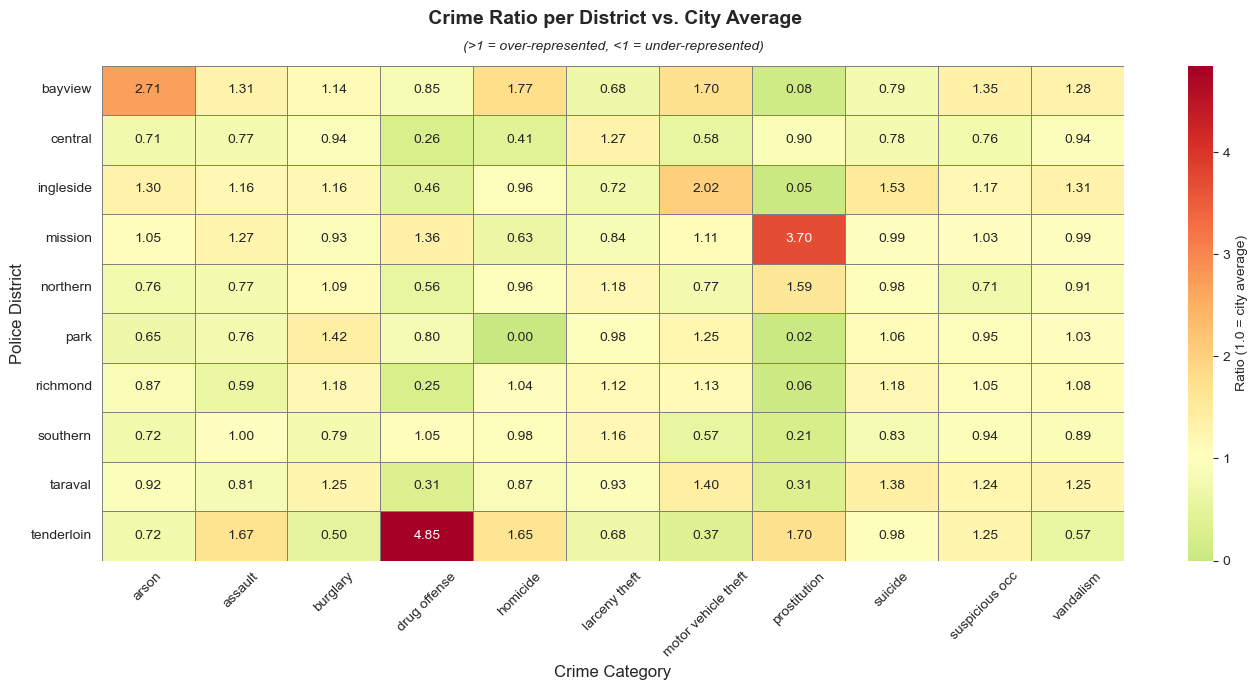

In [10]:
# --- PLOT 1: Crime ratio heatmap (over/under-representation per district) ---
fig, ax = plt.subplots(figsize=(14, 7))

sns.heatmap(
    crime_ratio,
    ax=ax,
    cmap="RdYlGn_r",
    center=1.0,
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    linecolor="grey",
    cbar_kws={"label": "Ratio (1.0 = city average)"}
)

# Create title with figure number
main_title = f" Crime Ratio per District vs. City Average"
subtitle = "(>1 = over-represented, <1 = under-represented)"
#fig_counter += 1

ax.set_title(main_title, fontsize=14, fontweight="bold", pad=30)
ax.text(0.5, 1.05, subtitle, transform=ax.transAxes,
        fontsize=10, ha='center', va='top', style='italic')

ax.set_xlabel("Crime Category", fontsize=12)
ax.set_ylabel("Police District", fontsize=12)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)

plt.tight_layout()
plt.show()

## Discussion of visualizations

### The Bayview district

Looking at the heatmap, two severe concentrations of _drug offense_ and _prostitution_ stand out, and in one district we find that only one crime, _larceny theft_, is over-represented. While we presume these patterns are somewhat easier to explain, we found Bayview to have a more atypical crime profile than any other. The Bayview area has a high rate of over-represented crimes, with _homicide_ and _arson_ being higher than any other police district. However, research shows that homicide rates in San Francisco have been [decreasing for years with a 60-year low in 2024](https://www.ppic.org/blog/homicides-in-california-have-decreased-dramatically/). When finding natural reasons for these higher numbers, our investigation of demographic and socio-economic characteristics revealed that, Bayview is [historically known as socially abandoned from the rest of San Francisco](https://en.wikipedia.org/wiki/Bayview–Hunters_Point,_San_Francisco) with higher concentration crime and gang activity. The area has faced economic challenges including unemployment though the [latest statistics](https://statisticalatlas.com/neighborhood/California/San-Francisco/Bayview/Overview) show increasing employment. Bayview is one of the [largest police district](https://www.sanfranciscopolice.org/stations/bayview-station) by area in San Francisco, which we found may contribute to higher arson counts. Despite its large area, our analysis shows Bayview has a generally lower total number of reported crimes compared to geographically smaller districts, suggesting the high ratio values are due to specific crime type concentrations rather than overall crime volume. Furthermore, we found external reports dated within the duration of the dataset showing [imprisonment rate of 206 per 100,000 people](https://www.prisonpolicy.org/origin/ca/2020/sanfrancisco_police.html) in 2020 in the Bayview district, which is the highest concentration in San Francisco, despite being the fifth most populated area. Based on these findings, we find the depicted crime profile might stand out, but this is not necessarily due to deficient police reporting or other problems in the data collection process, but rather due to the distinctive socio-economic demographic.

#### References
- [Homicides in California] (https://www.ppic.org/blog/homicides-in-california-have-decreased-dramatically/)
- [Bayview–Hunters Point, San Francisco] (https://en.wikipedia.org/wiki/Bayview%E2%80%93Hunters_Point,_San_Francisco)
- [Bayview Overview] (https://statisticalatlas.com/neighborhood/California/San-Francisco/Bayview/Overview)
- [Bayview Station] (https://www.sanfranciscopolice.org/stations/bayview-station)
- [Imprisonment rate] (https://www.prisonpolicy.org/origin/ca/2020/sanfrancisco_police.html)


---
## Assignment 1.3: Visualizing Distributions

This exercise asks you to recreate several classic plot types from DAOST Chapter 2 using your own crime data — putting visualization theory into practice.

*Draws from*: Week 3, Exercises 5.2 and 5.3.

> **Part A — Jitter plot**
> * Pick one of your Personal Focus Crimes and a suitable time interval (somewhere between a month and 6 months, depending on how common the crime is). Create a jitter plot of the incident times during a single hour (e.g. 13:00–14:00): let time run along the $x$-axis and add vertical jitter.
> * What does the jitter plot reveal about how times are recorded in the dataset? Are incidents clustered at certain minutes (on the hour, half hour, etc.)? What does this tell you about the precision of the data?

In [11]:
# Focus crime
df_larceny = df_fc[df_fc["incident_category"] == "larceny theft"]

# October 2019
df_oct = df_larceny[
    (df_larceny["incident_datetime"].dt.year == 2019) &
    (df_larceny["incident_datetime"].dt.month == 10)
    ]

# Hour 13
df_hour = df_oct[df_oct["incident_datetime"].dt.hour == 13]

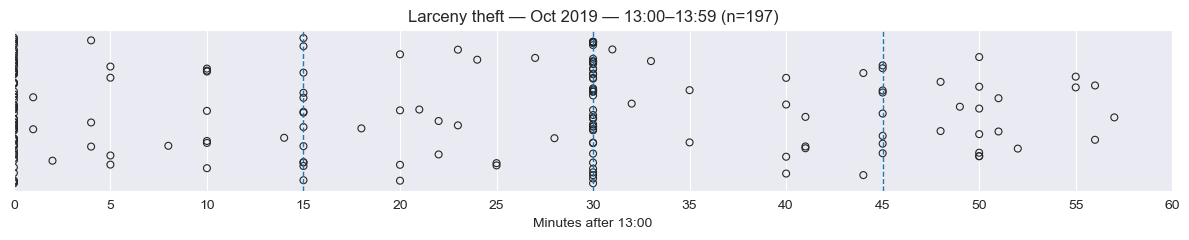

In [12]:
# x: minutes after 13:00 (decimal minutes keeps second info)
#global fig_counter
x_min = (
        df_hour["incident_datetime"].dt.minute +
        df_hour["incident_datetime"].dt.second / 60
).to_numpy()

rng = np.random.default_rng(1)
y = rng.uniform(-0.25, 0.25, size=len(x_min))

plt.figure(figsize=(12, 2.5))
plt.scatter(x_min, y, s=25, facecolors="none", edgecolors=plt.rcParams['text.color'], linewidths=0.8)
plt.yticks([])

# 5-minute ticks
plt.xticks(np.arange(0, 61, 5))
plt.xlim(0, 60)

plt.xlabel("Minutes after 13:00")
plt.title(f"Larceny theft — Oct 2019 — 13:00–13:59 (n={len(x_min)})")
#fig_counter += 1

# reference lines at :15, :30, :45
for v in (15, 30, 45):
    plt.axvline(v, linestyle="--", linewidth=1)

plt.tight_layout()
plt.show()

The jitter plot of larceny incident times in October 2019 (13:00–14:00) shows clear vertical clusters at :00, :15, :30, and :45, with the strongest concentrations at :00 and :30. This pattern indicates that many times are recorded with low temporal precision and are frequently rounded to the nearest quarter hour or full hour. The timestamps therefore appear to be administrative estimates rather than exact event times. The vertical jitter makes it possible to see how many incidents share the same recorded time, which would otherwise overlap in a standard dot plot.

> **Part B — Probability plot**
> * Using the same geographic data from Part B, create a probability plot (QQ plot) for the latitude distribution of each of your two crime types. (`scipy.stats.probplot` is your friend here.)
> * What reference distribution are you comparing against? What would it mean if the points fell exactly on the straight line? Where does the distribution deviate from normal, and what does that deviation tell you about the geography of crime in SF?

In [13]:
# Konverter decimal-komma → punkt og cast til float64
for col in ["latitude", "longitude"]:
    df_fc[col] = (
        df_fc[col]
        .astype(str)
        .str.replace(",", ".", regex=False)
    )
    df_fc[col] = pd.to_numeric(df_fc[col], errors="coerce")

# Drop rækker uden gyldige koordinater
df_fc = df_fc.dropna(subset=["latitude", "longitude"])

# Konservativ SF bounding box
df_fc = df_fc[
    (df_fc["latitude"].between(37.6, 37.9)) &
    (df_fc["longitude"].between(-122.55, -122.35))
    ].copy()

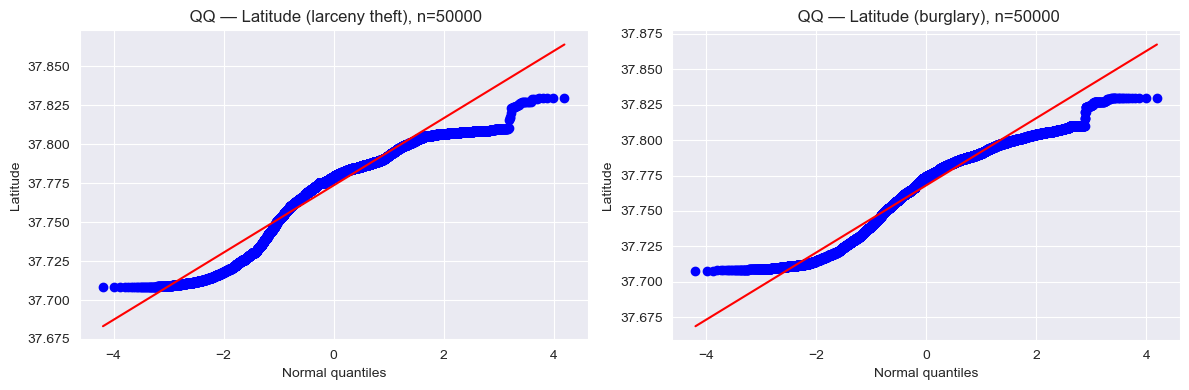

In [14]:
def qq_plot_lat(df, crime, ax, n_sample=50_000, seed=1):

    s = df.loc[df["incident_category"] == crime, "latitude"].dropna()

    # Sample for speed and reproducibility
    if len(s) > n_sample:
        s = s.sample(n=n_sample, random_state=seed)

    stats.probplot(s.to_numpy(dtype=np.float64), dist="norm", plot=ax)
    ax.set_title(f" QQ — Latitude ({crime}), n={len(s)}")
    ax.set_xlabel("Normal quantiles")
    ax.set_ylabel("Latitude")


fig, axes = plt.subplots(1, 2, figsize=(12, 4))


qq_plot_lat(df_fc, "larceny theft", axes[0])
qq_plot_lat(df_fc, "burglary", axes[1])

plt.tight_layout()
plt.show()

The QQ plots compare the latitude distributions to a normal (Gaussian) reference. If the points lay on the straight line, crime would form a single symmetric north–south band. Instead, the plots show an S-shape and flattened tails, indicating truncation and multiple spatial clusters. This reflects San Francisco’s geographic boundaries and the presence of distinct crime corridors rather than a single Gaussian pattern.

> **Part C — Box plots of time-of-day**
> * For each of your Personal Focus Crimes, extract the time-of-day of every incident.
> * Create box plots showing the time-of-day distribution for all your Personal Focus Crimes side by side.
> * What patterns do you see? Are there crimes that happen mostly at night? Mostly during business hours? For crimes that peak late at night, does the box plot handle the wrap-around at midnight well? What goes wrong?
> * Above, feel free to use alternatives to box plots — violin plots, swarm plots, or raincloud plots — if you think they reveal more. If you do, briefly explain what the alternative shows that the box plot doesn't.

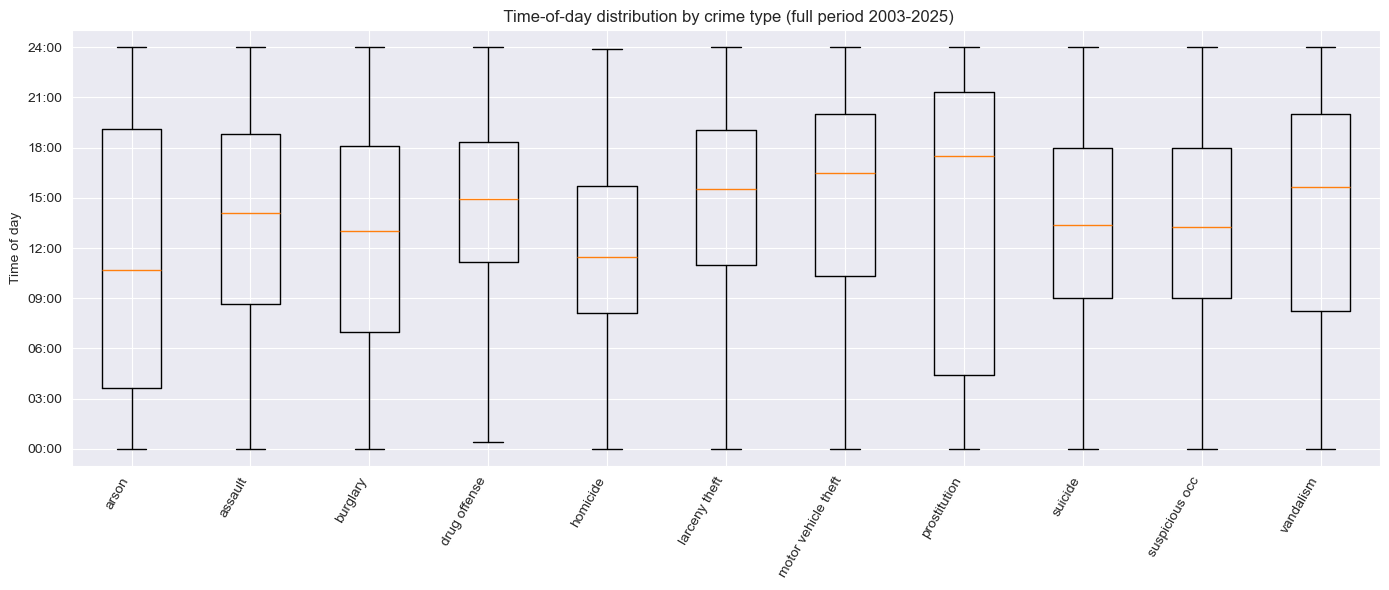

In [15]:
# Time-of-day as decimal hours from "HH:MM"
#global fig_counter
t = df_fc["incident_time"].astype(str)
df_fc["hour_decimal"] = t.str.slice(0, 2).astype(int) + t.str.slice(3, 5).astype(int) / 60

g = (
    df_fc.dropna(subset=["incident_category", "hour_decimal"])
    .groupby("incident_category")["hour_decimal"]
)

data = [s.to_numpy() for _, s in g]
labels = [name for name, _ in g]

plt.figure(figsize=(14, 6))
plt.boxplot(data, tick_labels=labels, showfliers=False)
plt.ylabel("Time of day")
plt.title(f" Time-of-day distribution by crime type (full period 2003-2025)")
#fig_counter += 1
plt.xticks(rotation=60, ha="right")

# Digital ticks every 3 hours (only 0–24 shown)
ytick = list(range(0, 25, 3))
ytick_labels = [f"{h:02d}:00" for h in ytick]
plt.yticks(ytick, ytick_labels)

# Give 1-hour margin without adding ticks
plt.ylim(-1, 25)

plt.tight_layout()
plt.show()

Property crimes such as larceny theft, burglary, and motor vehicle theft tend to cluster during daytime and business hours, with medians around midday to late afternoon. Violent and disorder-related crimes (e.g., assault, vandalism, arson) occur later in the day and into the evening, indicating a stronger nighttime component. Prostitution shows the latest median and a wide spread into the night.

For crimes that peak around midnight, the box plot does not handle the circular nature of time well. Because time wraps from 24:00 back to 00:00, events concentrated around 23:00–01:00 appear artificially spread across the entire day, shifting the median toward midday. This makes late-night clustering look broader and less concentrated than it actually is.

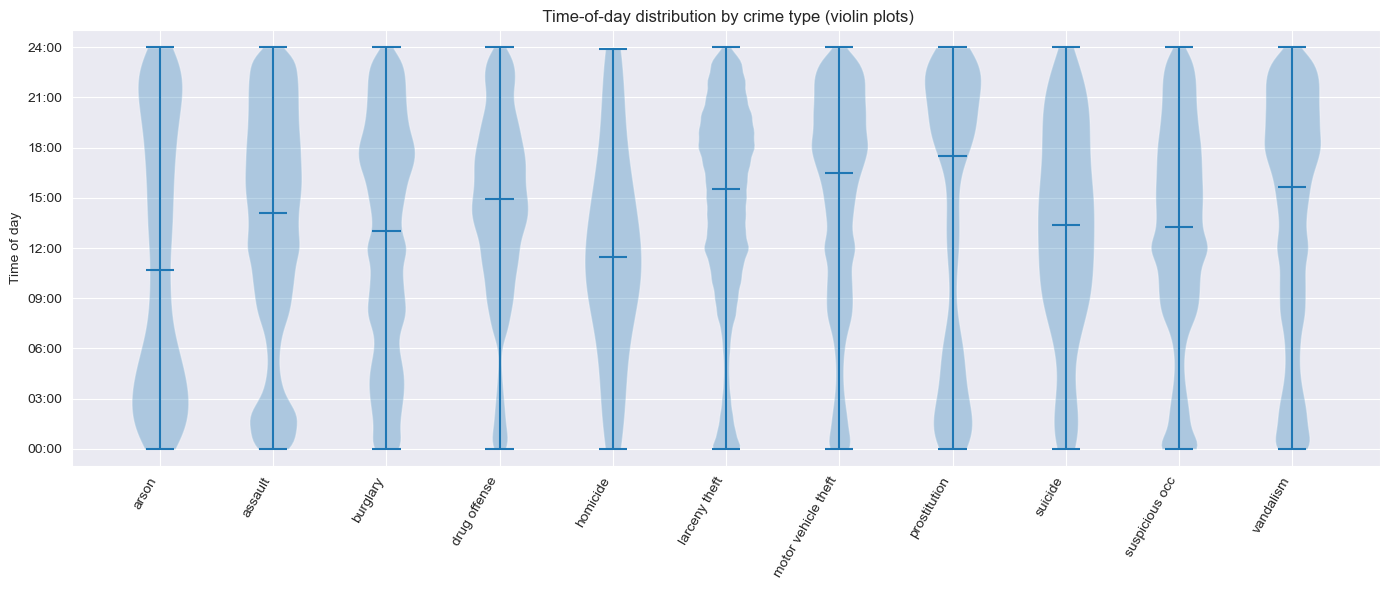

In [16]:
#global figure_counter
plt.figure(figsize=(14, 6))

vp = plt.violinplot(
    data,
    showmedians=True,  # show median line
    showextrema=True  # show min/max
)

plt.xticks(range(1, len(labels) + 1), labels, rotation=60, ha="right")
plt.ylabel("Time of day")
plt.title(f" Time-of-day distribution by crime type (violin plots)")
#fig_counter += 1

# Digital ticks every 3 hours (only 0–24 shown)
yticks = list(range(0, 25, 3))
ytick_labels = [f"{h:02d}:00" for h in yticks]
plt.yticks(yticks, ytick_labels)

# Same margin as before to avoid cropping
plt.ylim(-1, 25)

plt.tight_layout()
plt.show()

Violin plots improve on simple histograms and box plots by showing the full density of the data. They reveal multimodality, asymmetry, and the relative concentration of incidents across the day, rather than reducing the distribution to a few summary statistics. This makes it possible to see multiple activity peaks (e.g., morning and evening) that a box plot would hide.

However, violin plots still treat time as a linear variable from 00:00 to 24:00. Because time is circular, events clustered around midnight (e.g., 23:00–01:00) are split across the two ends of the axis. As a result, the median and spread are distorted, often appearing near midday with an artificially large variance. In other words, while violin plots show the shape better than simple distribution plots, they remain temporally naïve and cannot compute a correct “typical time” without a circular transformation.

In [17]:
# Extract hour (0–23) from "HH:MM"
t = df_fc["incident_time"].astype(str)
df_fc["hour"] = t.str.slice(0, 2).astype(int)

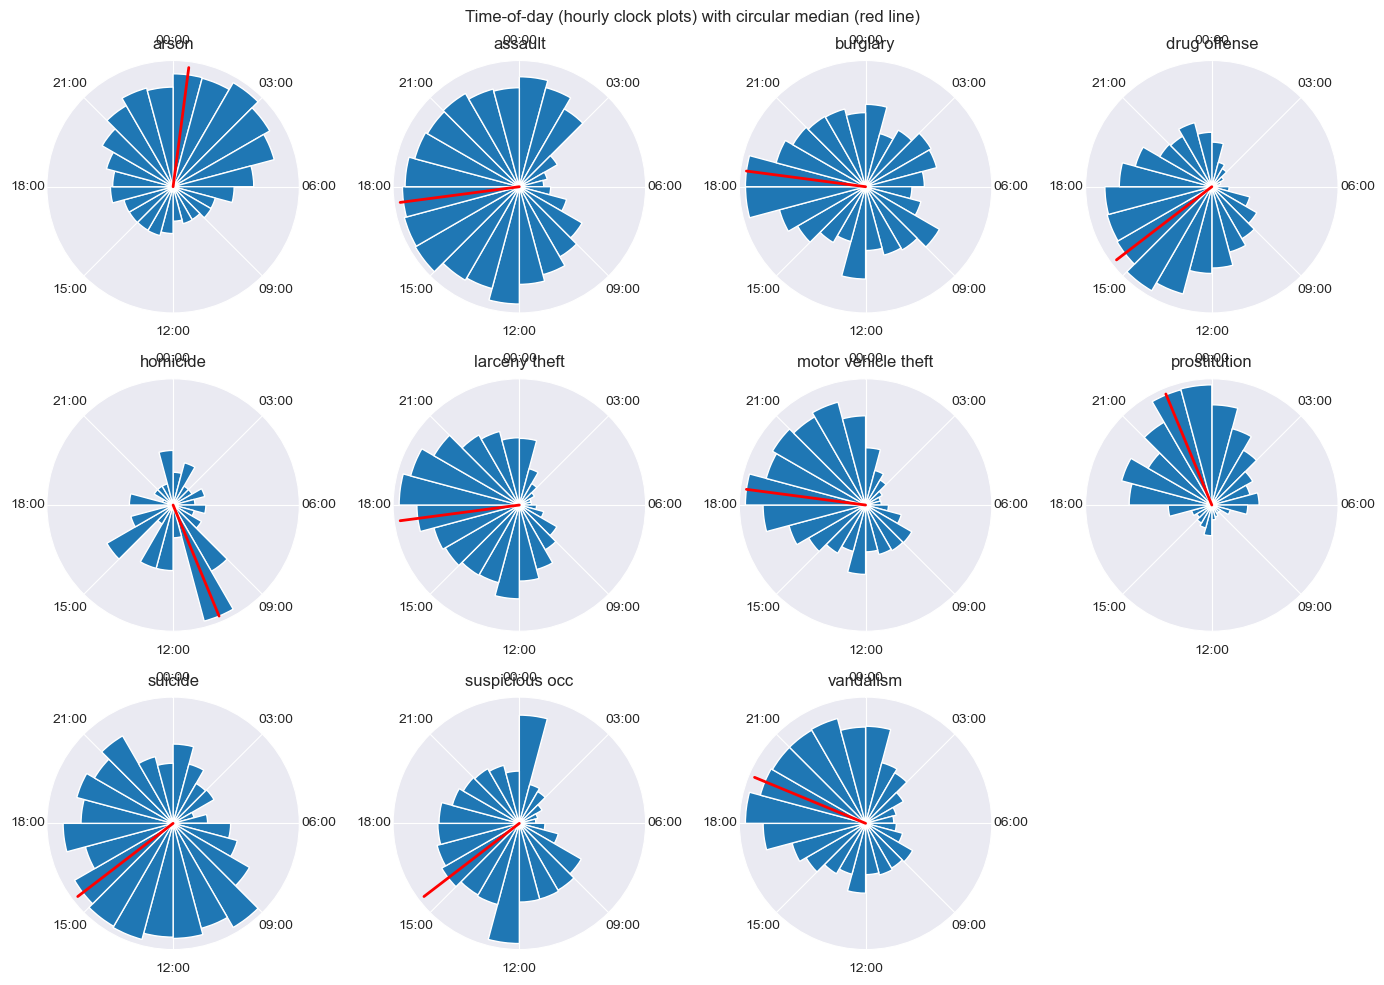

In [18]:
#global fig_counter
def ang_dist(a, b):
    """Smallest absolute angular distance on circle."""
    d = np.abs(a - b) % (2 * np.pi)
    return np.minimum(d, 2 * np.pi - d)

def weighted_circular_median(angles, weights):
    """
    Circular median as the angle that minimizes sum_i w_i * angular_distance(angle, angle_i).
    With 24 hourly bins, brute-force over candidates is fast and stable.
    """
    candidates = angles
    costs = np.array([np.sum(weights * ang_dist(c, angles)) for c in candidates])
    return candidates[np.argmin(costs)]

# Categories (all)
cats = sorted(df_fc["incident_category"].dropna().unique())

# Grid that fits 11 categories (3x4 = 12 slots)
fig, axes = plt.subplots(3, 4, figsize=(14, 10), subplot_kw={"projection": "polar"})
axes = axes.ravel()

# Hour bin geometry
hours = np.arange(24)
theta = 2 * np.pi * (hours / 24)  # bar start angles
width = 2 * np.pi / 24  # one hour

# Clock ticks every 3 hours
tick_hours = np.arange(0, 24, 3)
tick_angles = 2 * np.pi * (tick_hours / 24)
tick_labels = [f"{h:02d}:00" for h in tick_hours]

for ax, cat in zip(axes, cats):
    # Hour counts (0..23), fill missing hours with 0
    counts = (
        df_fc.loc[df_fc["incident_category"] == cat, "hour"]
        .value_counts()
        .reindex(hours, fill_value=0)
        .to_numpy()
    )

    # Bars: all incidents within each hour go into the same bar
    ax.bar(theta, counts, width=width, align="edge")

    # Circular median (weighted by counts, using hour centers)
    centers = theta + width / 2
    if counts.sum() > 0:
        theta_med = weighted_circular_median(centers, counts)
        ax.plot([theta_med, theta_med], [0, counts.max()], color="red", linewidth=2)

    # Clock formatting
    ax.set_title(cat, va="bottom")
    ax.set_theta_zero_location("N")  # 00:00 at top
    ax.set_theta_direction(-1)  # clockwise
    ax.set_xticks(tick_angles)
    ax.set_xticklabels(tick_labels)
    ax.set_yticks([])  # keep clean (counts already shown by bar length)

# Hide unused axis (12th slot)
for ax in axes[len(cats):]:
    ax.set_visible(False)

fig.suptitle(f"Time-of-day (hourly clock plots) with circular median (red line)", y=0.98)
#fig_counter += 1
plt.tight_layout()
plt.show()

The circular clock plots aggregate incidents into hourly bins and display them on a 24-hour cycle, so midnight is adjacent to 23:00. This preserves the true temporal structure and avoids the wrap-around distortion seen in linear box or violin plots.

The red line marks the circular median, i.e., the direction that minimizes the weighted angular distance to all observations. It provides a robust “typical time” even for distributions that span midnight.

Clear diurnal patterns emerge: property crimes concentrate during daytime and early evening, while several violent and disorder-related crimes peak later at night. Categories with broad activity show wide radial spread, whereas tightly timed crimes form narrow sectors. The method reveals both peak timing and dispersion without imposing a linear time assumption.

---
## Assignment 1.4: Spatial Power Law

Is crime spread evenly across San Francisco, or is it concentrated in a small number of hotspots? Let's find out.

*Draws from*: Week 4, Exercise 2.2.

Use your **most common Personal Focus Crime** (by total incident count) for this exercise.

> * **Step 1**: Divide San Francisco into a grid of approximately $100\text{m} \times 100\text{m}$ cells using latitude and longitude. It is fine to ignore that the Earth isn't flat — the approximation is good enough for this purpose.
>     * **Hint**: `np.histogram2d` works well here. Focus on points within the SF peninsula; filter out geographic outliers.
> * **Step 2**: Count the number of incidents of your chosen crime in each grid cell (use all years of data).
> * **Step 3**: Tally the distribution. Count how many cells have exactly $k$ incidents — call this $N(k)$ — for $k = 0, 1, 2, \ldots$ up to the maximum.
> * **Step 4**: Plot $(k+1)$ vs $N(k)$ on **linear axes**.
> * **Step 5**: Plot $(k+1)$ vs $N(k)$ on **loglog axes**.
> * **Step 6**: Does your crime follow a power-law spatial distribution? How can you tell from the loglog plot?
> * **Step 7**: If crime is spatially concentrated in a small number of cells, what does that imply for how we interpret neighborhood-level crime statistics? Does the "average block" tell you anything useful?

In [19]:
# Removing rows with empty/NaN in point, longitude, OR latitude
df_fc = df_fc.dropna(subset=['point', 'longitude', 'latitude']).copy()

# COUNT CATEGORIES
category_counts = df_fc['incident_category'].value_counts()

# FINDING THE MOST COMMON CATEGORY.
most_common_category = category_counts.idxmax()  # Dette er en string, fx "larceny theft"
most_common_count = category_counts.max()

# FILTERING OUT ALL OTHER CATEGORIES
df_fc = df_fc[df_fc['incident_category'] == most_common_category].copy()

---
#### 1.4 STEP 1 & 2 - Set bounds, create grid with counts

> * The datafile is imported.
> * Some Nan/empty is filtered away.
> * The categories are assessed as to find the one with the highest count.
> * The grid boundries are found via the dataset. We tested with manually setting the city (map) boundries, but this resulted in a much larger map
> * Number of cells is calculated.
> * grid is created with incident counts using np.nhistogram2d



In [20]:
# CREATE BOUNDRIES FOR SAN FRANSISCO.
lon_min, lon_max = df_fc['longitude'].min(), df_fc['longitude'].max()
lat_min, lat_max = df_fc['latitude'].min(), df_fc['latitude'].max()

# CONVERT DEGREES TO METERS AT SAN FRANCISCO LATITUDE (~37.7°)
meters_per_deg_lat = 111000  # METERS
meters_per_deg_lon = 88000  # METERS AT ~37.7° LATITUDE (LOOKED UP).

cell_size_meters = 100  # METERS PER TARGET CELL

# CALCULATE NUMBER OF BINS FOR ~100m CELLS
deg_per_cell_lat = cell_size_meters / meters_per_deg_lat
deg_per_cell_lon = cell_size_meters / meters_per_deg_lon
n_lat_bins = int((lat_max - lat_min) / deg_per_cell_lat)
n_lon_bins = int((lon_max - lon_min) / deg_per_cell_lon)

#  CREATE THE GRID.
sf_grid, lon_edges, lat_edges = np.histogram2d(
    df_fc['longitude'],
    df_fc['latitude'],
    bins=[n_lon_bins, n_lat_bins]
)

---
#### 1.4 STEP 3 - Tally distribution

> * The grid is flattened
> * The number of cells with each occurance is counted. A lot of value counts happened 0 times.



In [21]:
# FLATTEN THE GRID
cell_counts = sf_grid.flatten()

# COUNT HOW MANY CELLS THAT HAS EACH VALUE
# N(k)      = CELLS WITH EXACTLY k INCIDENTS
N_k = np.bincount(cell_counts.astype(int))

# k VALUES (0, 1, 2, 3, ...)
k_values = np.arange(len(N_k))

if False:
    print(f"\nDistribution:")
    print(f"k=0 (tomme celler): {N_k[0]} celler")
    print(f"k=1: {N_k[1]} celler")
    print(f"k=2: {N_k[2]} celler")

---
#### 1.4 STEP 4 - Plot (k+1) vs N(k) on
 linear axes

> * Elements where the value has not occured, are removed.
> * The distribution is plotted linearly

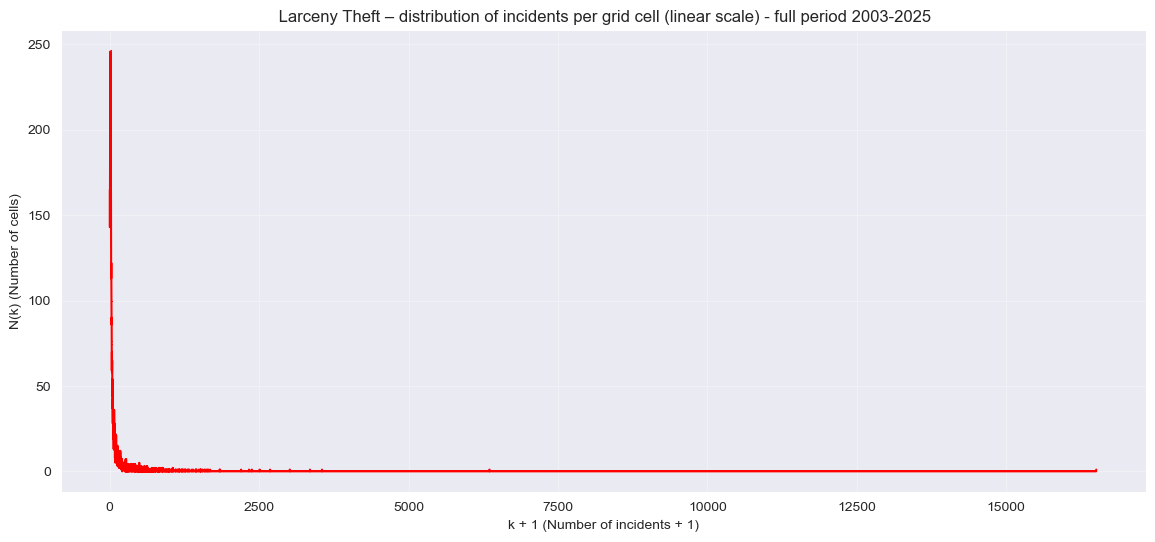

In [22]:
# REMOVING k=0 (EMPTY CELLS)

k_nonzero = k_values[1:]
N_k_nonzero = N_k[1:]

# CREATING THE LINEAR PLO
plt.figure(figsize=(14, 6))
plt.plot(k_nonzero + 1, N_k_nonzero, marker=',', color='red')
plt.xlabel('k + 1 (Number of incidents + 1)')
plt.ylabel('N(k) (Number of cells)')
plt.title(f' Larceny Theft – distribution of incidents per grid cell (linear scale) - full period 2003-2025')
#fig_counter += 1
plt.grid(True, alpha=0.3)
plt.show()

---
#### 1.4 STEP 5 - Plot (k+1) vs N(k) on loglog axes

> * Plotting on log scale

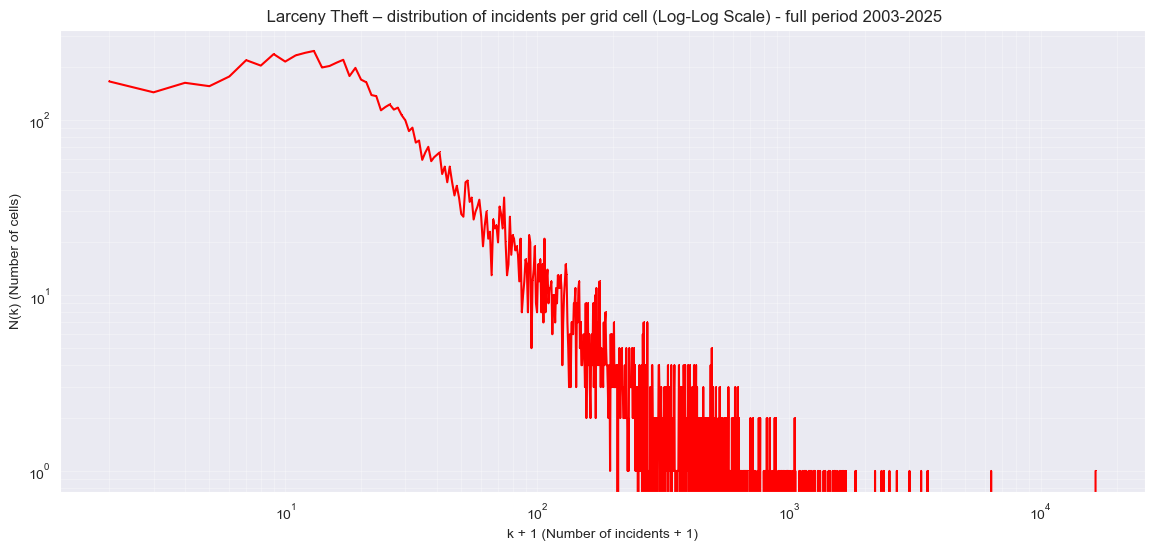

In [23]:

plt.figure(figsize=(14, 6))
plt.loglog(k_nonzero + 1, N_k_nonzero, marker=',', color='red')
plt.xlabel('k + 1 (Number of incidents + 1)')
plt.ylabel('N(k) (Number of cells)')
plt.title(f' Larceny Theft – distribution of incidents per grid cell (Log-Log Scale) - full period 2003-2025')

plt.grid(True, alpha=0.3, which='both')
plt.show()

---
#### 1.4 STEP 6 - Does it follow a power-law spatial distribution?

The Majority of the plot seems ot align with a line. Thus a power law distribution occurs between 10>k>500
As expected this shows that crime is concentrated in certain areas rather than evenly distributed. In this relation k = <10 are non significant.


---
#### 1.4 STEP 7 - What about average blocks

Average blocks will not be of much use, when assessing the risk of an incident of larceny theft in any specific area in San Fransisco. At best it can be used to compare average rates in San Francisco with other cities.


---
## 1.5 Regression and Correlation
In task 1.5 we are asked to find regression lines and correlation coefficients for crime types during the 168 hours of a week.
#### The change over time issue.
There are 22 years of data in the data set, and hence it is very likely that tendencies for a crime category has changes over time, even at hourly level, due to unknown factors we are not aware of, e.g., changes in legislations. We are utilizing the mean of incidents of a crime category on each hour at the day of a week across the dataset. We used the unique days in the dataset to ensure we are not calculating a weekday more than one time and to ensure days without incidents becomes null values.
#### Analyzed crime categories.
We have 11 focus crimes in our dataset (excluding noncriminal, warrant, and other offenses). To ensure we have a full 168-hour week for each crime category, we will create basic data of all 168 hours for each category and fill in the mean values, which will be 0 for hours without incidents.

#### Manual Regression Calculation
For each of the 66 crime pair, we calculate the regression line $y = mx + b$ using the least squares method:
$$
m = \frac{n \sum xy - \sum x \sum y}{n \sum x^2 - (\sum x)^2}
$$
$$
b = \frac{\sum y - m \sum x}{n}
$$
Where:
- $m$ is the slope
- $b$ is the y-intercept
- $n$ = 168 hours

### Pearson Correlation coefficient
$$r = m \times \frac{\sigma_x}{\sigma_y}$$
- $r$ = correlation coefficient
- $m$ = slope
- $\sigma_x$ = standard deviation of x values
- $\sigma_y$ = standard deviation of y values

In [24]:
# Prepare the hour column (extracting the '14' from '14:30')
# This creates a numeric column 0-23
df_fc_original['hour'] = pd.to_datetime(df_fc_original['incident_time'], format='%H:%M').dt.hour

# Get the denominators: How many unique dates exist for each weekday?
# (e.g., how many unique Mondays are in the 22-year dataset?)
day_counts = df_fc_original.groupby('incident_day_of_week')['incident_date'].nunique()

# Get the numerators: Total incidents per category, day, and hour
counts = df_fc_original.groupby(['incident_category', 'incident_day_of_week', 'hour']).size().reset_index(name='total_incidents')

# Calculate the Mean
counts['mean_incidents'] = counts['total_incidents'] / counts['incident_day_of_week'].map(day_counts)

In [25]:
# Get unique values to build the full 168-hour week for all 14 categories
categories = counts['incident_category'].unique()
weekdays = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
hours = range(24)

# Create the index
full_index = pd.MultiIndex.from_product(
    [categories, weekdays, hours],
    names=['incident_category', 'incident_day_of_week', 'hour']
)

# Reindex the data to fill missing hours with 0
# We set the index to match our skeleton, then reindex
final_df = counts.set_index(['incident_category', 'incident_day_of_week', 'hour'])
final_df = final_df.reindex(full_index, fill_value=0).reset_index()

In [26]:
# Pivot the data to ensure every category has exactly 168 rows
# Build full 168-slot MultiIndex (Monday 0-23, Tuesday 0-23, ..., Sunday 0-23)
day_order = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']

# Build the full 168-slot MultiIndex (all day/hour combinations)
full_week_index = pd.MultiIndex.from_product(
    [day_order, range(24)],
    names=['incident_day_of_week', 'hour']
)

pivot_df = counts.pivot_table(
    index=['incident_day_of_week', 'hour'],
    columns='incident_category',
    values='mean_incidents'
).reindex(full_week_index).fillna(0)  # now guaranteed 168 rows

# Extract into a dictionary of vectors
# Each vector will be a 1D NumPy array of length 168
vectors = {category: pivot_df[category].values for category in pivot_df.columns}


---
### Selection of crime categories.
We are asked to select a minimum of 4 crime categories and create scatter plot for comparison. We chose to visualize 8 out of 11 crime categories by excluding arson, suicide, and vandalism to focus on crimes that we unsubstantiated assume are more related, e.g., motor vehicle theft and burglary, or assault and drug offense. We plot the pairwise scatter plots in a 8x8 grid to get a good overview of the correlation between each crime.



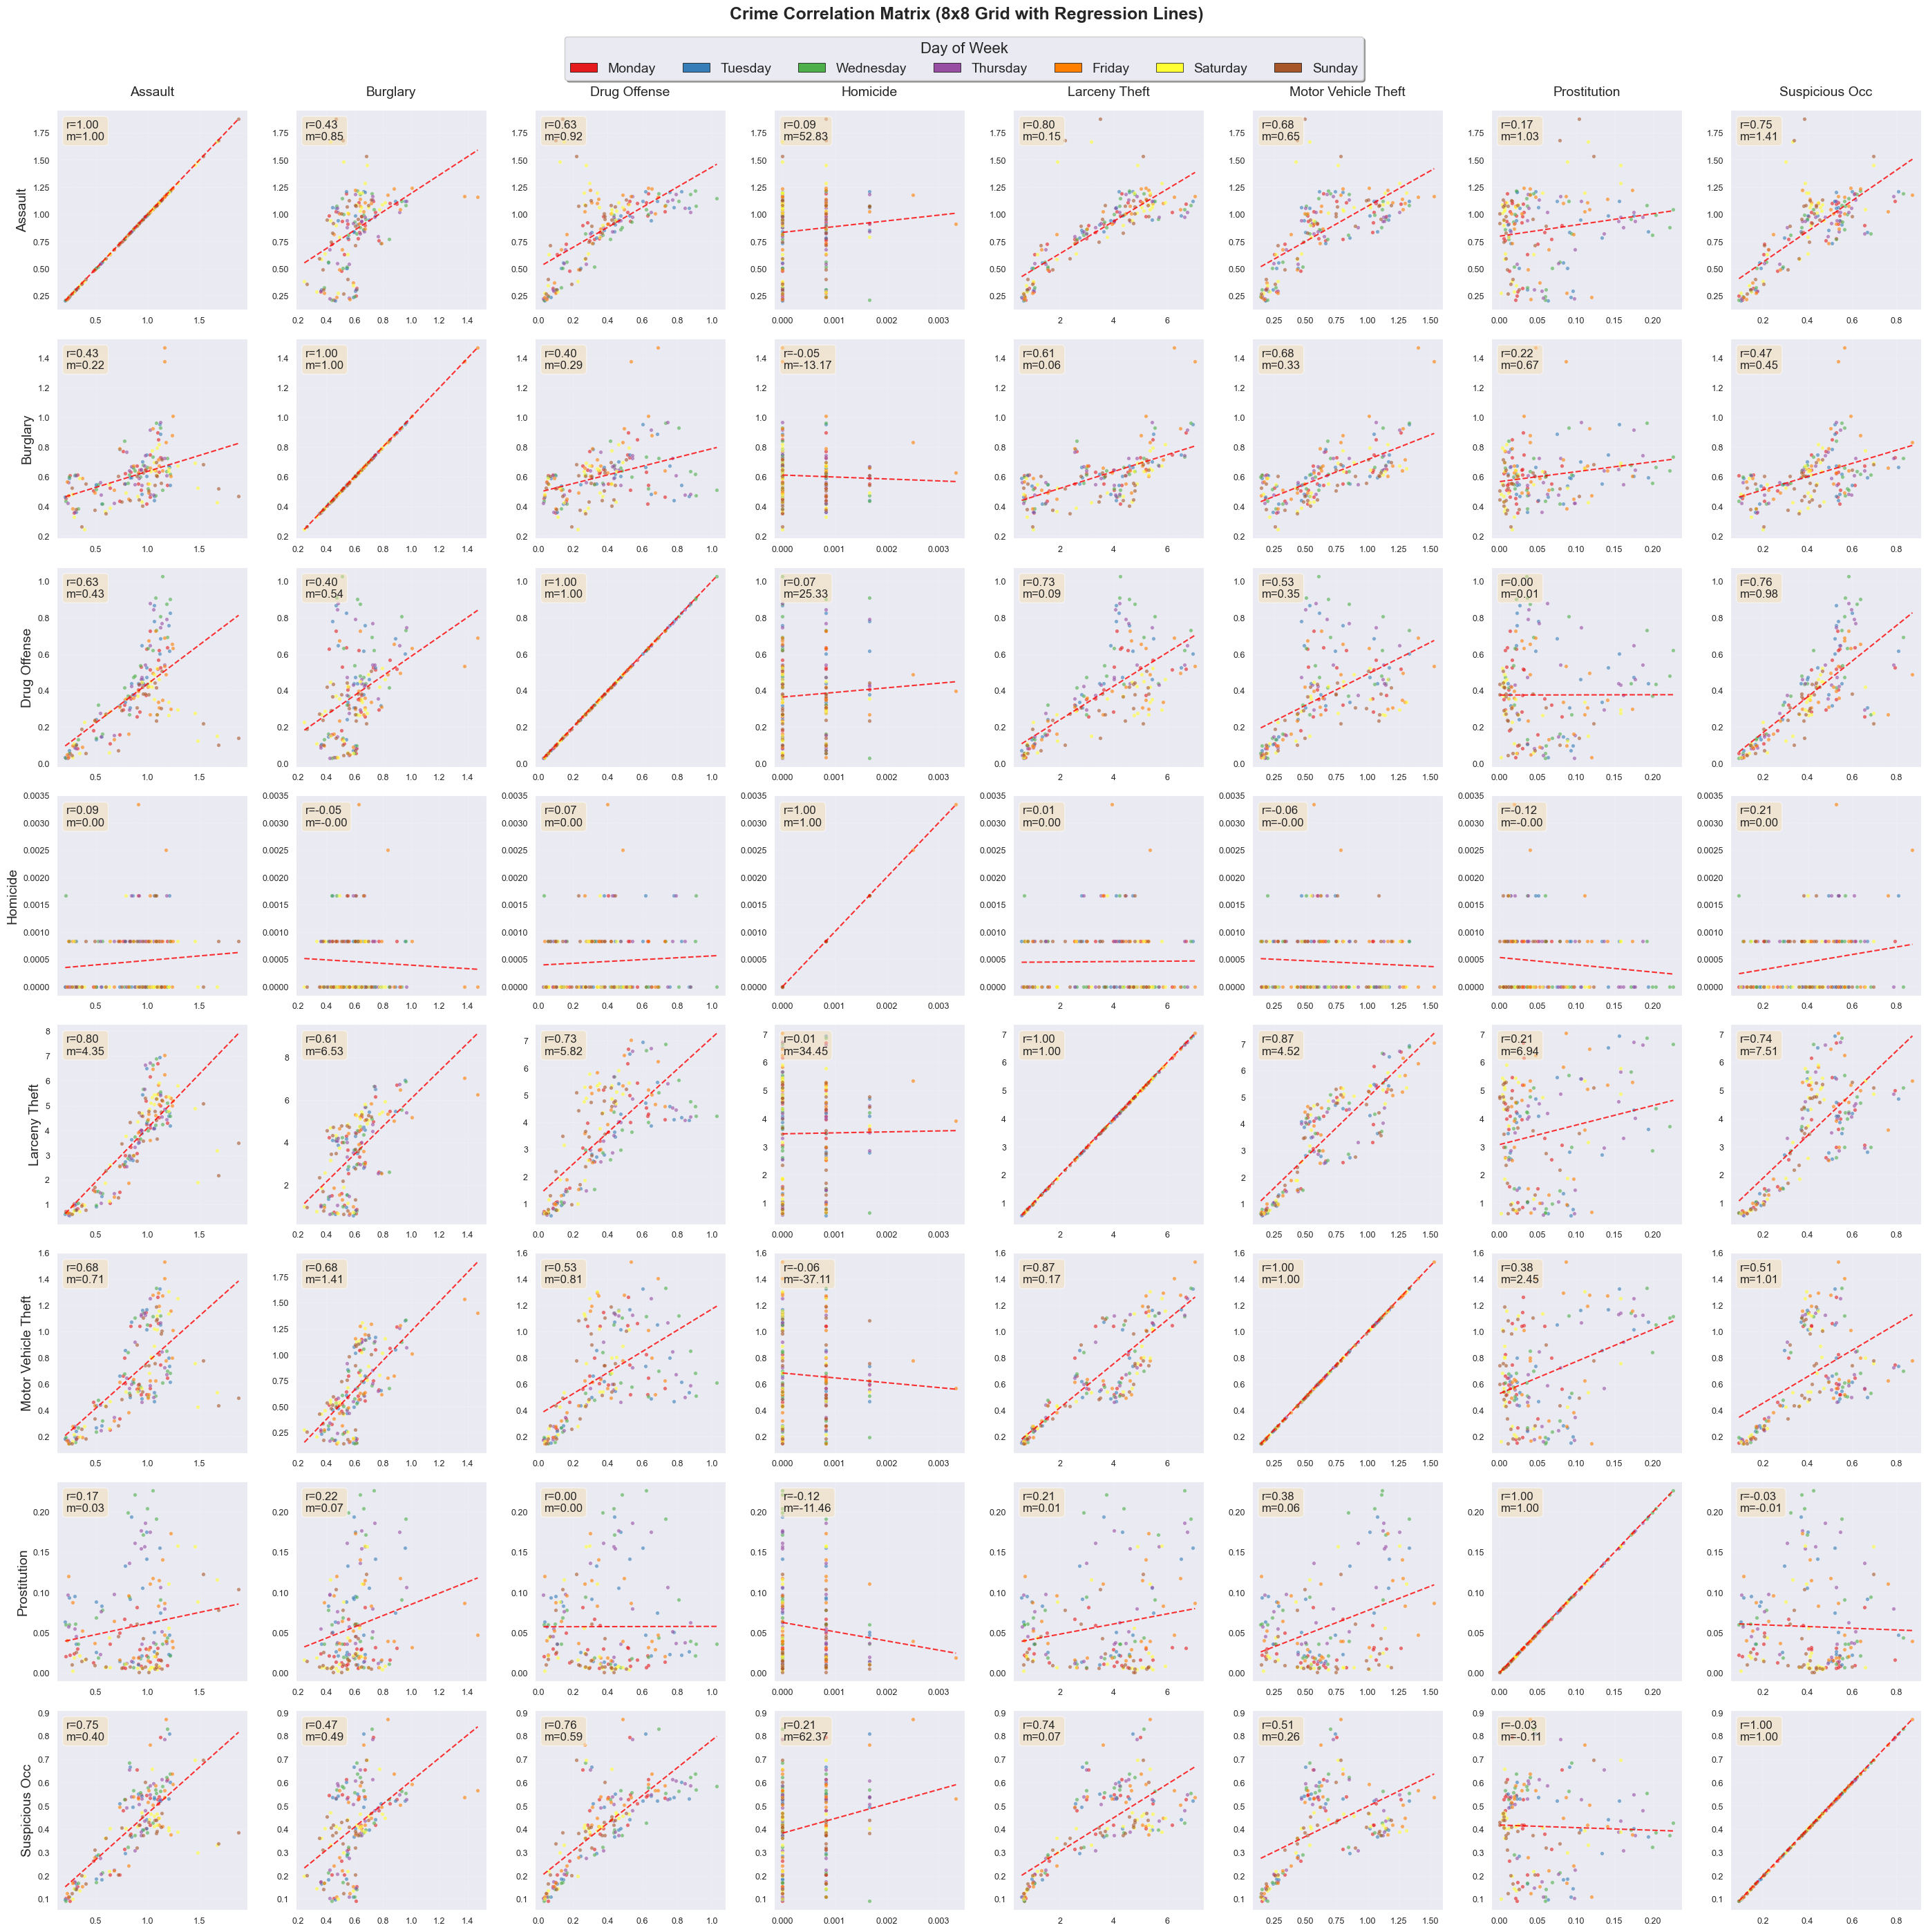

In [27]:
# 8x8 Grid of crime correlations with manual regression lines
from scipy.stats import pearsonr

# Get 8 crime categories, excluding arson, suicide, and vandalism
all_categories = sorted(vectors.keys())
exclude_from_grid = ['arson', 'suicide', 'vandalism']
crime_categories = [cat for cat in all_categories if cat not in exclude_from_grid][:8]

#print(f"Selected 8 crime categories for grid: {crime_categories}")

fig, axes = plt.subplots(8, 8, figsize=(28, 28))
fig.suptitle(f' Crime Correlation Matrix (8x8 Grid with Regression Lines)',
             fontsize=18, fontweight='bold', y=0.997)
#fig_counter += 1
day_order = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
cmap = plt.get_cmap('Set1')
colors = [cmap(i) for i in range(7)]

for i, y_cat in enumerate(crime_categories):  # i = row = Y-axis
    for j, x_cat in enumerate(crime_categories):  # j = column = X-axis
        ax = axes[i, j]

        # Extract vectors
        x_vals = vectors[x_cat]
        y_vals = vectors[y_cat]

        # Plot points colored by day
        for day_idx, day in enumerate(day_order):
            idx_start = day_idx * 24
            idx_end = (day_idx + 1) * 24
            ax.scatter(
                x_vals[idx_start:idx_end],
                y_vals[idx_start:idx_end],
                color=colors[day_idx],
                s=15,
                alpha=0.6,
                edgecolor='white',
                linewidth=0.2
            )

        # Manual linear regression calculation
        n = len(x_vals)
        sum_x = x_vals.sum()
        sum_y = y_vals.sum()
        sum_xy = (x_vals * y_vals).sum()
        sum_x_squared = (x_vals ** 2).sum()

        # Calculate slope (m) and intercept (b)
        m = (n * sum_xy - sum_x * sum_y) / (n * sum_x_squared - sum_x ** 2)
        b = (sum_y - m * sum_x) / n

        # Draw regression line
        x_min, x_max = x_vals.min(), x_vals.max()
        x_line = np.array([x_min, x_max])
        y_line = m * x_line + b
        ax.plot(x_line, y_line, 'r--', linewidth=1.5, alpha=0.8)

        # Calculate correlation
        correlation, p_value = pearsonr(x_vals, y_vals)

        # Set labels - X-axis on top row, Y-axis on left column
        if i == 0:  # Top row - add X labels
            ax.set_title(x_cat.replace('_', ' ').title(), fontsize=14, pad=15)
        if j == 0:  # Left column - add Y labels
            ax.set_ylabel(y_cat.replace('_', ' ').title(), fontsize=14)

        # Add correlation coefficient as text
        ax.text(0.05, 0.95, f'r={correlation:.2f}\nm={m:.2f}',
                transform=ax.transAxes, fontsize=12,
                verticalalignment='top',
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

        ax.grid(True, alpha=0.3, linestyle='--', linewidth=0.5)
        ax.tick_params(labelsize=9)

# Create horizontal legend bar at the top
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=colors[i], edgecolor='black', linewidth=0.5, label=day.capitalize())
                   for i, day in enumerate(day_order)]
fig.legend(handles=legend_elements,
           loc='upper center',
           bbox_to_anchor=(0.5, 0.985),  # Moved down slightly to create more space
           ncol=7,
           fontsize=14,
           title='Day of Week',
           title_fontsize=16,
           frameon=True,
           fancybox=True,
           shadow=True)

plt.tight_layout(rect=[0, 0, 1, 0.975])  # Adjusted to leave more space at top
plt.show()

### Findings in the scatter plot.
We plotted 36 unique pairwise plots displaying both the _Pearson correlation coefficient_ (**r**) and the _slope_ (**m**) for each pair.

- **r** measures how strongly two crimes correlated.
- **m** measures the steepness of the regression line.

### Finding strongest and weakest correlations.
The positive correlation will tell us which pairs have similar patterns, meaning they tend to have high values and low values at the same hours of the week, while the negatively correlated have opposite patterns. The weakly correlated pairs do not have any clear pairwise patterns.

We find that **_motor vehicle theft_** and **_larceny theft_** have the strongest positive correlation with Pearson's coefficient r=0.87 and we find the strongest negative correlation between **_prostitution_** and **_homicide_** with r=-0.0624. The weakest correlation we find between **_prostitution_** and **_drug offense_** with r=0.0036, which is very close to zero, indicating no linear relationship.

We expected to find a strong positive correlation between motor vehicle theft and burglary, as we assumed burglars need to transport tools and stolen property. We found that the strong negative correlation between prostitution and homicide does not yield a significant pattern. This is mainly caused by homicide that seems to have no correlation with any other crimes in the parts of the dataset we selected, and maybe not to any. The near-zero correlation between prostitution and drug offense suggests that these two crime types do not have a linear relationship in their temporal patterns. This could be explained by the drugs and the sexual activity in prostitution, are not happening at the same time.
We find that positive pairwise correlations coefficients tend to be much higher, than the negatively correlated. This shows that crimes in San Francisco tends to increase at the same time of the day. However, as the plots show there are only a few strongly correlated crimes. This could be attributed to noisy data or the fact that crimes can not be seen as derived from each other.

For the best overview of the whole dataset we generated the top 10 strongest positively correlated crime pairs and the top 10 strongest negative pairs, as well as the 10 weakest correlations, as seen below. Furthermore, we created an interactive two-dimensional scatter plot including the regression line and correlation coefficient for the selected pair. This way we are able to plot any 11 focus crimes against each other and choose which weekdays to emphasize.


In [28]:
# Calculate correlations between all crime category pairs
crime_categories = sorted(vectors.keys())
n_categories = len(crime_categories)

# Store all correlation results
correlations = []

for i, cat1 in enumerate(crime_categories):
    for j, cat2 in enumerate(crime_categories):
        if i < j:  # Only calculate upper triangle (avoid duplicates and self-correlation)
            x_vals = vectors[cat1]
            y_vals = vectors[cat2]

            correlation, p_value = pearsonr(x_vals, y_vals)

            correlations.append({
                'crime_1': cat1,
                'crime_2': cat2,
                'correlation': correlation,
                'p_value': p_value,
                'abs_correlation': abs(correlation)
            })

# Create dataframe and sort
corr_df = pd.DataFrame(correlations)

# Find most correlated pairs (highest positive correlation)
print("=" * 80)
print("TOP 10 MOST POSITIVELY CORRELATED CRIME PAIRS")
print("=" * 80)
most_correlated = corr_df.nlargest(10, 'correlation')
for idx, row in most_correlated.iterrows():
    print(f"{row['crime_1']:20s} ↔ {row['crime_2']:20s} | r = {row['correlation']:6.3f} (p = {row['p_value']:.4f})")

print("\n" + "=" * 80)
print("TOP 10 MOST NEGATIVELY CORRELATED CRIME PAIRS")
print("=" * 80)
least_correlated = corr_df.nsmallest(10, 'correlation')
for idx, row in least_correlated.iterrows():
    print(f"{row['crime_1']:20s} ↔ {row['crime_2']:20s} | r = {row['correlation']:6.3f} (p = {row['p_value']:.4f})")

print("\n" + "=" * 80)
print("TOP 10 WEAKEST CORRELATIONS (closest to zero)")
print("=" * 80)
weakest_corr = corr_df.nsmallest(10, 'abs_correlation')
for idx, row in weakest_corr.iterrows():
    print(f"{row['crime_1']:20s} ↔ {row['crime_2']:20s} | r = {row['correlation']:6.3f} (p = {row['p_value']:.4f})")

print("\n" + "=" * 80)
print(f"SUMMARY: Total of {len(correlations)} unique crime pairs analyzed")
print(f"Average correlation: {corr_df['correlation'].mean():.3f}")
print(f"Median correlation: {corr_df['correlation'].median():.3f}")
print("=" * 80)


TOP 10 MOST POSITIVELY CORRELATED CRIME PAIRS
motor vehicle theft  ↔ vandalism            | r =  0.930 (p = 0.0000)
larceny theft        ↔ motor vehicle theft  | r =  0.872 (p = 0.0000)
assault              ↔ larceny theft        | r =  0.804 (p = 0.0000)
larceny theft        ↔ vandalism            | r =  0.803 (p = 0.0000)
drug offense         ↔ suspicious occ       | r =  0.762 (p = 0.0000)
assault              ↔ suspicious occ       | r =  0.747 (p = 0.0000)
larceny theft        ↔ suspicious occ       | r =  0.736 (p = 0.0000)
drug offense         ↔ larceny theft        | r =  0.733 (p = 0.0000)
assault              ↔ vandalism            | r =  0.718 (p = 0.0000)
burglary             ↔ motor vehicle theft  | r =  0.685 (p = 0.0000)

TOP 10 MOST NEGATIVELY CORRELATED CRIME PAIRS
arson                ↔ drug offense         | r = -0.507 (p = 0.0000)
arson                ↔ suicide              | r = -0.495 (p = 0.0000)
arson                ↔ suspicious occ       | r = -0.439 (p = 0.000

In [29]:
# Interactive Plotly scatter plot with dropdown selectors


# Get all crime categories
crime_categories = sorted(vectors.keys())

# Create dropdowns
x_dropdown = widgets.Dropdown(
    options=crime_categories,
    value='prostitution',
    description='X axis:'
)
y_dropdown = widgets.Dropdown(
    options=crime_categories,
    value='assault',
    description='Y axis:'
)
output = widgets.Output()


def update_plot(change):
    with output:
        output.clear_output(wait=True)

        x_cat = x_dropdown.value
        y_cat = y_dropdown.value

        # Create dataframe with selected crime categories
        day_order = ['monday', 'tuesday', 'wednesday', 'thursday', 'friday', 'saturday', 'sunday']
        plot_data = []

        for i, day in enumerate(day_order):
            for hour in range(24):
                idx = i * 24 + hour
                plot_data.append({
                    'day': day,
                    'hour': hour,
                    'x_value': vectors[x_cat][idx],
                    'y_value': vectors[y_cat][idx]
                })

        plot_df = pd.DataFrame(plot_data)

        # Calculate correlation
        correlation, p_value = pearsonr(plot_df['x_value'], plot_df['y_value'])

        # Manual linear regression calculation using least squares
        # y = mx + b
        # m = (n*Σ(xy) - Σx*Σy) / (n*Σ(x²) - (Σx)²)
        # b = (Σy - m*Σx) / n

        x_vals = plot_df['x_value'].values
        y_vals = plot_df['y_value'].values
        n = len(x_vals)

        sum_x = x_vals.sum()
        sum_y = y_vals.sum()
        sum_xy = (x_vals * y_vals).sum()
        sum_x_squared = (x_vals ** 2).sum()

        # Calculate slope (m) and intercept (b)
        m = (n * sum_xy - sum_x * sum_y) / (n * sum_x_squared - sum_x ** 2)
        b = (sum_y - m * sum_x) / n

        # Generate regression line points
        x_min, x_max = x_vals.min(), x_vals.max()
        x_line = np.array([x_min, x_max])
        y_line = m * x_line + b

        # Create Plotly figure
        fig = px.scatter(
            plot_df,
            x='x_value',
            y='y_value',
            color='day',
            hover_data={
                'day': True,
                'hour': True,
                'x_value': ':.3f',
                'y_value': ':.3f'
            },
            color_discrete_sequence=px.colors.qualitative.Set1,
            labels={
                'x_value': f'Mean {x_cat.title()} Incidents',
                'y_value': f'Mean {y_cat.title()} Incidents',
                'day': 'Day of Week',
                'hour': 'Hour'
            },
            title=f'Interactive Correlation: {x_cat.title()} vs {y_cat.title()}<br><sub>Pearson r = {correlation:.3f} (p = {p_value:.4f}) | y = {m:.3f}x + {b:.3f}</sub>'
        )

        # Add regression line manually calculated
        fig.add_scatter(
            x=x_line,
            y=y_line,
            mode='lines',
            name='Regression Line',
            line=dict(color='red', width=2, dash='dash'),
            showlegend=True
        )

        fig.update_traces(marker=dict(size=8, line=dict(width=0.5, color='white')), selector=dict(mode='markers'))
        fig.update_layout(
            width=900,
            height=600,
            hovermode='closest'
        )

        fig.show()


# Attach event handlers
x_dropdown.observe(update_plot, names='value')
y_dropdown.observe(update_plot, names='value')

# Display widgets
display(widgets.HBox([x_dropdown, y_dropdown]))
display(output)

# Initial plot
update_plot(None)

Output()

### Work distribution

All participated and developed the solutions in unison with an equal distribution. 

- s195377 - Niels Christian Grønlykke
- s206073 - Morten Deurell
- s215000 - Andreas R. Holm-Hansen

Group a1 25